In [2]:
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("results/boot_results_vqa.csv")
df = df.drop(columns=["path", "have_eval_result",
             "have_prediction", "have_gpt_score", "if_finished", "error"])

df

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high
0,Qwen2-VL,vqa,SLAKE,general,ZS,Qwen,0.779962,0.737981,0.819712
1,Qwen25-VL,vqa,SLAKE,general,ZS,Qwen,0.755822,0.713942,0.798077
2,Gemma3,vqa,SLAKE,general,ZS,Gemma,0.721779,0.680288,0.764423
3,MedGemma,vqa,SLAKE,medical,ZS,Gemma,0.770599,0.730769,0.810096
4,InternVL3,vqa,SLAKE,general,ZS,Intern,0.744175,0.701863,0.786058
...,...,...,...,...,...,...,...,...,...
215,gemini-2.5-pro,vqa,OmniMedVQA,medical,ucagent,Gemini,NaN,NaN,NaN
216,o3,vqa,OmniMedVQA,medical,mdagent,o-family,NaN,NaN,NaN
217,o3,vqa,OmniMedVQA,medical,ucagent,o-family,NaN,NaN,NaN
218,Lingshu,vqa,OmniMedVQA,medical,mdagent,Qwen,0.816583,0.806656,0.826220


In [4]:
ID_dict = {
    "LLaVA-Med": ["VQA-RAD", "PathVQA", "SLAKE"],
    "MedGemma": ["VQA-RAD", "PathVQA", "SLAKE"],
    "Lingshu": ["VQA-RAD", "PathVQA", "SLAKE"],
    # "gemini-2.5-pro": ["VQA-RAD", "PathVQA", "SLAKE", "Harvard-FairVLMed10k"],
    # "o3": ["VQA-RAD", "PathVQA", "SLAKE", "Harvard-FairVLMed10k"],
}

is_ood = []

for dataset, model in zip(df["dataset"].tolist(), df["model"].tolist()):
    if not model in ID_dict.keys():
        is_ood.append(1)
    elif dataset not in ID_dict[model]:
        is_ood.append(1)
    else:
        is_ood.append(0)

df["is_ood"] = is_ood

In [5]:
df["model_family"].unique()

array(['Qwen', 'Gemma', 'Intern', 'LLaVA', 'Gemini', 'o-family'],
      dtype=object)

# heatmap

In [6]:
df["dataset+tune_module"] = df["dataset"] + "-" + df["trainable_module"]

model_order = [
    # "o3",
    # "gemini-2.5-pro",
    "LLaVA-1.5",
    "LLaVA-Med",
    "Qwen2-VL",
    "Qwen25-VL",
    "Lingshu",
    "Gemma3",
    "MedGemma",
    # "VILA",
    # "VILA-M3",
    "InternVL3",
]

data_order = [
    "VQA-RAD-ZS",
    "VQA-RAD-mdagent",
    "VQA-RAD-ucagent",
    "PathVQA-ZS",
    "PathVQA-mdagent",
    "PathVQA-ucagent",
    "SLAKE-ZS",
    "SLAKE-mdagent",
    "SLAKE-ucagent",
    "Harvard-FairVLMed10k-ZS",
    "Harvard-FairVLMed10k-mdagent",
    "Harvard-FairVLMed10k-ucagent",
    "MedXpertQA-ZS",
    "MedXpertQA-mdagent",
    "MedXpertQA-ucagent",
    "OmniMedVQA-ZS",
    "OmniMedVQA-mdagent",
    "OmniMedVQA-ucagent",
]

metric = "acc"
df_plot = df.copy(deep=True)
df_plot = df_plot.loc[~df_plot["model"].isin(["VILA", "VILA-M3"])]

df_plot[metric] = df_plot[metric] * 100

data_heatmap = df_plot.pivot(index="model", columns="dataset+tune_module", values=metric)
data_heatmap = data_heatmap.reindex(model_order, axis=0)
data_heatmap = data_heatmap.reindex(data_order, axis=1)
data_heatmap

dataset+tune_module,VQA-RAD-ZS,VQA-RAD-mdagent,VQA-RAD-ucagent,PathVQA-ZS,PathVQA-mdagent,PathVQA-ucagent,SLAKE-ZS,SLAKE-mdagent,SLAKE-ucagent,Harvard-FairVLMed10k-ZS,Harvard-FairVLMed10k-mdagent,Harvard-FairVLMed10k-ucagent,MedXpertQA-ZS,MedXpertQA-mdagent,MedXpertQA-ucagent,OmniMedVQA-ZS,OmniMedVQA-mdagent,OmniMedVQA-ucagent
model,,,,,,,,,,,,,,,,,,
LLaVA-1.5,52.445020,48.914343,39.870916,54.725193,47.537151,38.297353,63.995433,64.794712,48.319952,45.434419,50.250651,39.408968,NaN,NaN,NaN,51.916133,46.855739,38.321015
LLaVA-Med,69.790837,59.755777,68.227490,66.000803,66.183254,65.997829,62.342308,54.685817,59.450962,76.128808,72.187074,75.826152,NaN,NaN,NaN,20.633463,23.685209,31.518477
Qwen2-VL,75.225498,72.445020,65.286853,68.274390,67.758626,65.629774,77.996154,72.368269,64.679327,58.582064,61.515130,61.026102,21.7980,22.51900,19.28875,69.131975,64.890753,61.671807
Qwen25-VL,70.827092,67.350996,64.121116,62.358477,61.477097,65.030458,75.582212,72.756490,69.494231,61.417134,57.897846,57.416283,24.0095,18.47025,14.48825,64.019253,61.388425,55.378694
Lingshu,70.474900,68.510757,58.056574,81.527365,80.287091,63.187448,77.694471,77.005529,73.611298,66.157164,64.331112,43.382665,24.7795,23.71700,24.54600,83.417087,81.658261,NaN
Gemma3,58.247012,61.710757,57.635458,76.212344,62.107644,62.471505,72.177885,67.525000,66.141106,66.645892,55.772244,43.702906,20.7230,15.74950,17.25475,36.327918,59.866052,59.519156
MedGemma,76.424701,76.424701,76.542231,70.665229,66.284830,65.191106,77.059856,85.161298,81.499279,61.613176,58.117285,58.899449,22.2085,22.97375,26.96850,69.512868,71.621532,69.993986
InternVL3,70.202390,75.315936,65.663745,70.862909,67.596550,63.903926,74.417548,80.103125,74.786058,60.735371,62.028758,NaN,23.5140,22.72125,NaN,75.673295,79.736195,NaN


In [7]:
mask = df_plot.pivot(
    index="model", columns="dataset+tune_module", values="is_ood")
mask = mask.reindex(model_order, axis=0)
mask = mask.reindex(data_order, axis=1)
mask

dataset+tune_module,VQA-RAD-ZS,VQA-RAD-mdagent,VQA-RAD-ucagent,PathVQA-ZS,PathVQA-mdagent,PathVQA-ucagent,SLAKE-ZS,SLAKE-mdagent,SLAKE-ucagent,Harvard-FairVLMed10k-ZS,Harvard-FairVLMed10k-mdagent,Harvard-FairVLMed10k-ucagent,MedXpertQA-ZS,MedXpertQA-mdagent,MedXpertQA-ucagent,OmniMedVQA-ZS,OmniMedVQA-mdagent,OmniMedVQA-ucagent
model,,,,,,,,,,,,,,,,,,
LLaVA-1.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0
LLaVA-Med,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,1.0,1.0
Qwen2-VL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Qwen25-VL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Lingshu,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Gemma3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
MedGemma,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
InternVL3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [8]:
mask.shape

(8, 18)

# heatmap

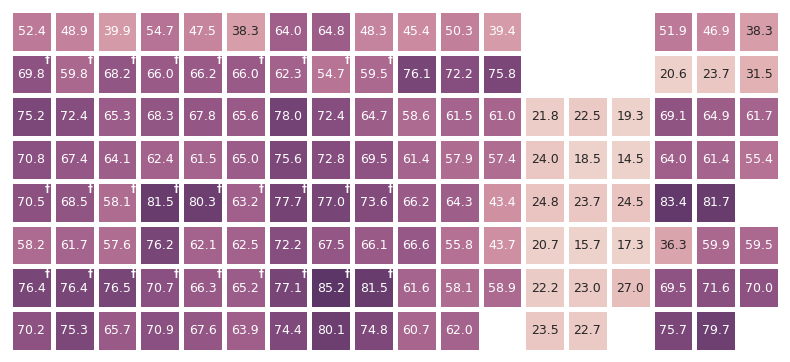

In [11]:
def prepare_annot_for_heatmap(data):
    annot = np.array(data).copy()
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            annot[i, j] = "{:.1f}".format(float(annot[i, j]))
    return annot


scale = 1
fig, ax = plt.subplots(figsize=(mask.shape[0] * scale, mask.shape[1] * scale))

heat = sns.heatmap(
    data_heatmap,
    cbar=False,
    cmap=sns.cubehelix_palette(as_cmap=True),
    annot=prepare_annot_for_heatmap(data_heatmap),
    ax=ax,
    yticklabels=False,
    xticklabels=False,
    fmt="",
    square=True,
    linewidths=2.5 * scale,
    annot_kws={"size": 9},
    vmin=20,
    vmax=100,
)

mask = np.array(mask).astype(bool)


# Add asterisks to the specified cells
for i in range(data_heatmap.shape[0]):
    for j in range(data_heatmap.shape[1]):
        if not mask[i, j]:  # Check if the cell is marked for asterisk
            ax.text(
                j + 0.88,  # Adjust position slightly to the right of the cell
                i + 0.18,  # Center vertically
                "†",
                color="white",  # Asterisk color (contrast with heatmap)
                fontsize=7,
                ha="center",
                va="center",
                weight="bold",
            )

ax.tick_params(right=False, left=True, labelleft=False)
# ax.set_yticks(np.arange(8) + 0.5)
# ax.set_xticks(np.arange(12) + 0.5)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    "figures/vqa_agent_heatmap",
    dpi=400,
    bbox_inches="tight",
)

# family-wise comparison

In [66]:
datasets = ["VQA-RAD", "PathVQA", "SLAKE", "Harvard-FairVLMed10k", "MedXpertQA", "OmniMedVQA"]
model_families = {
    "LLaVA": [
        "LLaVA-Med",
        "LLaVA-1.5",
    ],
    "Qwen": [
        "Lingshu",
        "Qwen2-VL",
        "Qwen25-VL",
    ],
    "Gemma": [
        "MedGemma",
        "Gemma3",
    ],
}

palette = sns.color_palette("Set2", len(datasets))
color_dict = dict(zip(datasets, palette))

color_dict

{'VQA-RAD': (0.4, 0.7607843137254902, 0.6470588235294118),
 'PathVQA': (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 'SLAKE': (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 'Harvard-FairVLMed10k': (0.9058823529411765,
  0.5411764705882353,
  0.7647058823529411),
 'MedXpertQA': (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 'OmniMedVQA': (1.0, 0.8509803921568627, 0.1843137254901961)}

In [67]:
def get_general_medical_df_sub(df, rq, family):
    df_sub = df.loc[(df["trainable_module"].isin(["ZS", "ML"])) & (df["model_family"] == family)]
    if rq == 1:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["trainable_module"] == "ZS")]
        df_sub_medical = df_sub.loc[(df_sub["model_type"] == "medical") & (df_sub["trainable_module"] == "ZS")]
    elif rq == 2:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["trainable_module"] == "ML")]
        df_sub_medical = df_sub.loc[
            (df_sub["model_type"] == "medical") & (df_sub["trainable_module"] == "ZS") & (df_sub["is_ood"] == 0)
        ]
    elif rq == 3:
        df_sub_general = df_sub.loc[(df_sub["model_type"] == "general") & (df_sub["trainable_module"] == "ML")]
        df_sub_medical = df_sub.loc[
            (df_sub["model_type"] == "medical") & (df_sub["trainable_module"] == "ML") & (df_sub["is_ood"] == 1)
        ]

    df_sub = pd.concat([df_sub_general, df_sub_medical]).reset_index(drop=True)
    df_sub = df_sub.loc[df_sub["dataset"].isin(df_sub_medical["dataset"].unique())]

    return df_sub, df_sub_general, df_sub_medical

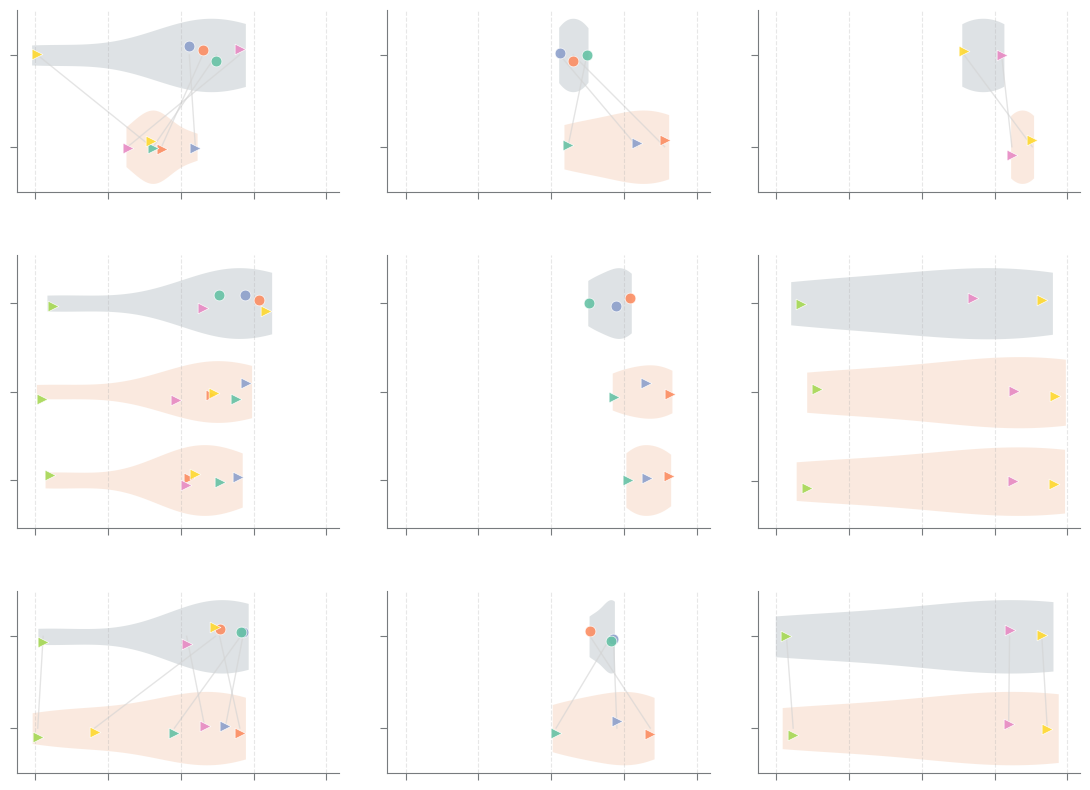

In [68]:
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon

fig, axes = plt.subplots(3, 3, figsize=(11, 8), gridspec_kw={"height_ratios": [2, 3, 2]}, sharex=True)

# 淡色 violin 颜色
violin_palette = {
    "medical": "#cfd8dc",  # 淡蓝灰
    "general": "#ffe0cc",  # 淡橙灰
}

for rq in range(1, 4):
    for idx_family, family in enumerate(model_families.keys()):
        cur_ax = axes[idx_family, rq - 1]

        df_sub, df_sub_general, df_sub_medical = get_general_medical_df_sub(df, rq, family)

        #  ================================
        # 排序：medical(Set1)在上，general(Set2)在下
        # ================================
        # 不同模型名称顺序
        model_order = model_families[family]

        # 不同dataset
        datasets_unique = df_sub["dataset"].unique()

        # ================================
        # 1️⃣ Violin 分两次画（按model_type）
        # ================================
        for mtype in ["medical", "general"]:
            df_tmp = df_sub[df_sub["model_type"] == mtype]

            if len(df_tmp) > 0:
                sns.violinplot(
                    data=df_tmp,
                    y="model",
                    x="acc",
                    order=model_order,
                    ax=cur_ax,
                    inner=None,
                    linewidth=0,
                    color=violin_palette[mtype],
                    cut=0.1,
                    alpha=0.7,
                )

        # ================================
        # 2️⃣ Scatter + y轴 jitter
        # ================================
        y_positions = {model: i for i, model in enumerate(model_order)}

        for d in datasets_unique:
            df_d = df_sub[df_sub["dataset"] == d]

            for _, row in df_d.iterrows():
                y_base = y_positions[row["model"]]

                # 加小幅 jitter
                y_jitter = y_base + np.random.uniform(-0.1, 0.1)

                is_ood = row["is_ood"]

                marker_style = "o" if is_ood == 0 else ">"

                cur_ax.scatter(
                    row["acc"],
                    y_jitter,
                    color=color_dict[d],
                    s=60,
                    alpha=0.9,
                    zorder=3,
                    marker=marker_style,
                    edgecolor="white",
                    linewidth=0.5,
                )

        # ================================
        # 3️⃣ 两模型时加 paired 线
        # ================================
        if len(model_order) == 2:
            for d in datasets_unique:
                df_d = df_sub[df_sub["dataset"] == d].sort_values("model")
                if len(df_d) == 2:
                    y0 = y_positions[df_d.iloc[0]["model"]]
                    y1 = y_positions[df_d.iloc[1]["model"]]

                    cur_ax.plot(
                        df_d["acc"].values,
                        [y0, y1],
                        color="lightgray",
                        alpha=0.6,
                        linewidth=1,
                        zorder=1,
                    )

        # ================================
        # 美化
        # ================================
        cur_ax.set_xlabel("")
        cur_ax.set_ylabel("")
        # cur_ax.set_title(f"{family} - RQ{rq}")

        cur_ax.grid(axis="x", linestyle="--", alpha=0.3)
        # cur_ax.grid(axis="y", linestyle="--", alpha=0.3)

        cur_ax.spines["top"].set_visible(False)
        # cur_ax.spines["bottom"].set_visible(False)
        cur_ax.spines["right"].set_visible(False)

        cur_ax.spines["bottom"].set_color("#777b7e")
        cur_ax.spines["left"].set_color("#777b7e")
        cur_ax.spines["bottom"].set_linewidth(0.8)
        cur_ax.spines["left"].set_linewidth(0.8)

        cur_ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1])
        cur_ax.set_xticklabels([])
        cur_ax.set_yticklabels([])

        cur_ax.tick_params(
            axis="both",  # x 和 y 都设置
            which="both",  # major + minor
            direction="out",  # 向外
            length=5,  # tick 长度
            width=0.8,  # tick 线宽
            colors="#777b7e",  # tick 颜色
        )

        # break

    # break


plt.tight_layout()
fig.subplots_adjust(hspace=0.3, wspace=0.15)

plt.savefig(
    "figures/vqa_family_compare",
    dpi=400,
    bbox_inches="tight",
)

In [69]:
for rq in range(1, 4):
    for idx_family, family in enumerate(model_families.keys()):
        df_sub, df_sub_general, df_sub_medical = get_general_medical_df_sub(df, rq, family)

        # ================================
        # LMM
        # ================================

        # 只保留 medical/general
        df_lmm = df_sub.copy()

        # 确保分类变量
        df_lmm["model_type"] = df_lmm["model_type"].astype("category")

        # 设定 reference = medical（可改）
        df_lmm["model_type"] = df_lmm["model_type"].cat.reorder_categories(["medical", "general"], ordered=True)

        # Mixed model
        model = smf.mixedlm("acc ~ model_type", df_lmm, groups=df_lmm["dataset"])

        result = model.fit()

        beta = result.params["model_type[T.general]"]
        ci_low, ci_high = result.conf_int().loc["model_type[T.general]"]
        p_value = result.pvalues["model_type[T.general]"]

        print("\n" + "-" * 40)
        print(f"{family} - RQ{rq}")
        print(f"β = {beta:.3f}")
        print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}]")
        print(f"p = {p_value:.4f}")

        # ================================
        # paired p value
        # ================================

        model_order = model_families[family]
        # 1️⃣ 设置有序 categorical
        df_sub["model"] = pd.Categorical(df_sub["model"], categories=model_order, ordered=True)

        # 2️⃣ 排序 dataframe
        df_sub = df_sub.sort_values("model")

        medical_models = df_sub[df_sub["model_type"] == "medical"]["model"].unique()
        general_models = df_sub[df_sub["model_type"] == "general"]["model"].unique()

        # 初始化矩阵
        p_matrix = pd.DataFrame(np.nan, index=medical_models, columns=general_models)

        annot_matrix = pd.DataFrame("", index=medical_models, columns=general_models)

        for m_med in medical_models:
            for m_gen in general_models:

                df_med = df_sub[df_sub["model"] == m_med][["dataset", "acc"]]
                df_gen = df_sub[df_sub["model"] == m_gen][["dataset", "acc"]]

                df_pair = df_med.merge(df_gen, on="dataset", suffixes=("_med", "_gen"))

                n_pair = len(df_pair)

                if n_pair >= 2:
                    stat, p = wilcoxon(df_pair["acc_med"], df_pair["acc_gen"])

                    p_matrix.loc[m_med, m_gen] = p
                    annot_matrix.loc[m_med, m_gen] = f"p={p:.3f} n={n_pair}"
                else:
                    annot_matrix.loc[m_med, m_gen] = f"n={n_pair}"

        print(annot_matrix)

/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/


----------------------------------------
LLaVA - RQ1
β = -0.053
95% CI = [-0.255, 0.149]
p = 0.6085
             LLaVA-1.5
LLaVA-Med  p=0.812 n=5

----------------------------------------
Qwen - RQ1
β = -0.066
95% CI = [-0.115, -0.017]
p = 0.0084
            Qwen2-VL    Qwen25-VL
Lingshu  p=0.219 n=6  p=0.062 n=6

----------------------------------------
Gemma - RQ1
β = -0.079
95% CI = [-0.200, 0.042]
p = 0.2030
               Gemma3
MedGemma  p=0.562 n=6


/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.188132
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/ana


----------------------------------------
LLaVA - RQ2
β = 0.137
95% CI = [-0.022, 0.297]
p = 0.0918
             LLaVA-1.5
LLaVA-Med  p=0.500 n=3

----------------------------------------
Qwen - RQ2
β = 0.094
95% CI = [0.075, 0.112]
p = 0.0000
            Qwen2-VL    Qwen25-VL
Lingshu  p=0.250 n=3  p=0.250 n=3

----------------------------------------
Gemma - RQ2
β = 0.008
95% CI = [-0.145, 0.161]
p = 0.9187
               Gemma3
MedGemma  p=0.750 n=3

----------------------------------------
LLaVA - RQ3
β = 0.108
95% CI = [-0.007, 0.223]
p = 0.0661
             LLaVA-1.5
LLaVA-Med  p=0.500 n=2

----------------------------------------
Qwen - RQ3
β = 0.059
95% CI = [0.023, 0.094]
p = 0.0011
            Qwen2-VL    Qwen25-VL
Lingshu  p=0.250 n=3  p=0.250 n=3

----------------------------------------
Gemma - RQ3
β = 0.010
95% CI = [-0.002, 0.023]
p = 0.1150
               Gemma3
MedGemma  p=0.500 n=3


/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.188286
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/anaconda3/envs/vlmbenchmark/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/yesindeed/ana

# cross-family test

In [70]:
def try_fetch(list, index):
    try:
        return list[index]
    except:
        return None


def get_med_stats(df, metric):
    assert len(df["dataset"].unique()) == 1
    dataset = df["dataset"].unique()[0]

    df_med = df.loc[df["model_type"] == "medical"]
    df_zs = df_med.loc[(df_med["trainable_module"] == "ZS")]
    df_sft = df_med.loc[(df_med["trainable_module"] == "ML") & (df_med["is_ood"] == 1)]

    zs_metric = np.sort(
        np.array(df_zs[metric]),
    )
    sft_metric = np.sort(
        np.array(df_sft[metric]),
    )
    zs_metric = zs_metric[~np.isnan(zs_metric)]
    sft_metric = sft_metric[~np.isnan(sft_metric)]

    best_zs, second_zs = try_fetch(zs_metric, -1), try_fetch(zs_metric, -2)
    best_sft, second_sft = try_fetch(sft_metric, -1), try_fetch(sft_metric, -2)

    return (best_zs, second_zs), (best_sft, second_sft)


def update_min(current_min, value):
    return min(current_min, value)


def update_max(current_max, value):
    return max(current_max, value)


def build_fake_bootstrap(df, n_samples=1000):
    rows = []

    for _, row in df.iterrows():
        mean = row["acc"]
        ci_low = row["ci_low"]
        ci_high = row["ci_high"]

        # 估计标准差
        std = (ci_high - ci_low) / (2 * 1.96)

        samples = np.random.normal(mean, std, n_samples)

        for s in samples:
            new_row = row.copy()
            new_row["acc"] = s
            rows.append(new_row)

    return pd.DataFrame(rows)


def generate_gradient(hex_color, n=6):
    """
    从深色生成 n 个从浅到深的颜色渐变（hex 格式）
    """
    import matplotlib.colors as mcolors
    import numpy as np

    # 深色 RGB
    deep_rgb = np.array(mcolors.to_rgb(hex_color))

    # 生成从白色到深色的线性插值
    colors = []
    for i in np.linspace(0.0, 1.0, n):
        rgb = (1 - i) * np.array([1, 1, 1]) + i * deep_rgb
        colors.append(mcolors.to_hex(rgb))
    return colors[1:5] + [colors[-1]]

/tmp/ipykernel_2434237/70941818.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["acc"] *= 100
/tmp/ipykernel_2434237/70941818.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["ci_low"] *= 100
/tmp/ipykernel_2434237/70941818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html

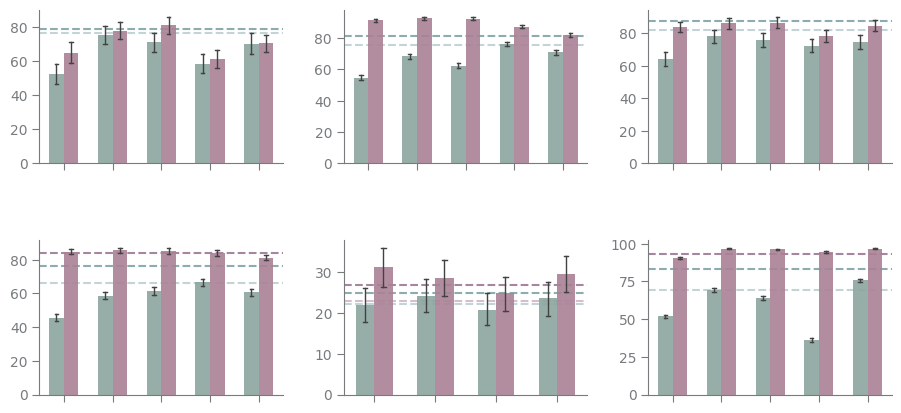

In [78]:
model_order = [
    "LLaVA-1.5",
    "Qwen2-VL",
    "Qwen25-VL",
    "Gemma3",
    "InternVL3",
]

data_order = [
    "VQA-RAD",
    "PathVQA",
    "SLAKE",
    "Harvard-FairVLMed10k",
    "MedXpertQA",
    "OmniMedVQA",
]

metric = "acc"

fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharey=False)

for i_plot, dataset in enumerate(data_order):
    cur_ax = axes[i_plot // 3, i_plot % 3]

    df_plot = df.loc[(df["dataset"] == dataset) & (df["trainable_module"].isin(["ZS", "ML"]))]
    df_plot["acc"] *= 100
    df_plot["ci_low"] *= 100
    df_plot["ci_high"] *= 100

    min_value, max_value = df_plot[metric].min(), df_plot[metric].max()
    (best_med_zs, second_med_zs), (best_med_sft, second_med_sft) = get_med_stats(df_plot, metric)

    if best_med_zs is not None:
        min_value = update_min(min_value, best_med_zs)
        max_value = update_max(max_value, best_med_zs)
        cur_ax.axhline(y=best_med_zs, color=generate_gradient("#5c898e")[4], ls="--", lw=1.5, zorder=1, alpha=0.7)
    if second_med_zs is not None:
        min_value = update_min(min_value, second_med_zs)
        max_value = update_max(max_value, second_med_zs)
        cur_ax.axhline(y=second_med_zs, color=generate_gradient("#5c898e")[1], ls="--", lw=1.5, zorder=1, alpha=0.9)
    if best_med_sft is not None:
        min_value = update_min(min_value, best_med_sft)
        max_value = update_max(max_value, best_med_sft)
        cur_ax.axhline(y=best_med_sft, color=generate_gradient("#80517a")[4], ls="--", lw=1.5, zorder=1, alpha=0.7)
    if second_med_sft is not None:
        if abs(best_med_sft - second_med_sft) > 3:
            min_value = update_min(min_value, second_med_sft)
            max_value = update_max(max_value, second_med_sft)
            cur_ax.axhline(
                y=second_med_sft, color=generate_gradient("#80517a")[1], ls="--", lw=1.5, zorder=1, alpha=0.9
            )

    min_ylim, max_ylim = int(min_value / 10) * 10, (int(max_value / 10) + 1) * 10
    max_ylim = min(100, max_ylim)

    df_general = df_plot.loc[(df_plot["model_type"] == "general") & (df_plot["trainable_module"].isin(["ZS", "ML"]))]
    df_general["model"] = pd.Categorical(df_general["model"], categories=model_order, ordered=True)
    df_general = df_general.sort_values(by="model")

    df_boot = build_fake_bootstrap(df_general).reset_index(drop=True)

    sns.barplot(
        data=df_boot,
        x="model",
        y="acc",
        hue="trainable_module",
        hue_order=["ZS", "ML"],
        errorbar=("pi", 95),  # ✅ percentile interval
        err_kws={"linewidth": 1},
        n_boot=0,  # ✅ 不再重新bootstrap
        ax=cur_ax,
        palette=["#86aaa0", "#b17a96"],
        legend=False,
        capsize=0.15,
        width=0.6,
        gap=0,
        alpha=0.9,
    )

    # ================================
    # 美化
    # ================================
    cur_ax.set_xlabel("")
    cur_ax.set_ylabel("")
    # cur_ax.set_title(f"{family} - RQ{rq}")

    # cur_ax.grid(axis="y", linestyle="--", alpha=0.3)

    cur_ax.spines["top"].set_visible(False)
    # cur_ax.spines["bottom"].set_visible(False)
    cur_ax.spines["right"].set_visible(False)

    cur_ax.spines["bottom"].set_color("#777b7e")
    cur_ax.spines["left"].set_color("#777b7e")
    cur_ax.spines["bottom"].set_linewidth(0.8)
    cur_ax.spines["left"].set_linewidth(0.8)

    # cur_ax.set_xticks([0.4, 0.6, 0.8, 1])
    cur_ax.set_xticklabels([])
    # cur_ax.set_yticklabels([])

    cur_ax.tick_params(
        axis="both",  # x 和 y 都设置
        which="both",  # major + minor
        direction="out",  # 向外
        length=5,  # tick 长度
        width=0.8,  # tick 线宽
        colors="#777b7e",  # tick 颜色
    )

plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.savefig(
    "figures/vqa_cross_family_bar.png",
    dpi=1000,
    bbox_inches="tight",
)

In [21]:
df_plot

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high,is_ood,dataset+tune_module
48,Qwen2-VL,vqa,OmniMedVQA,general,ZS,Qwen,69.131975,67.959909,70.320886,1,OmniMedVQA-ZS
49,Qwen25-VL,vqa,OmniMedVQA,general,ZS,Qwen,64.019253,62.835435,65.212173,1,OmniMedVQA-ZS
50,Gemma3,vqa,OmniMedVQA,general,ZS,Gemma,64.255884,63.013256,65.421920,1,OmniMedVQA-ZS
51,MedGemma,vqa,OmniMedVQA,medical,ZS,Gemma,70.353864,69.187682,71.435500,1,OmniMedVQA-ZS
52,InternVL3,vqa,OmniMedVQA,general,ZS,Intern,75.673295,74.587375,76.753961,1,OmniMedVQA-ZS
53,LLaVA-1.5,vqa,OmniMedVQA,general,ZS,LLaVA,51.916133,50.726641,53.153896,1,OmniMedVQA-ZS
54,LLaVA-Med,vqa,OmniMedVQA,medical,ZS,LLaVA,34.741174,33.575816,35.952554,1,OmniMedVQA-ZS
55,gemini-2.5-pro,vqa,OmniMedVQA,medical,ZS,Gemini,NaN,NaN,NaN,1,OmniMedVQA-ZS
56,o3,vqa,OmniMedVQA,medical,ZS,o-family,NaN,NaN,NaN,1,OmniMedVQA-ZS
57,Lingshu,vqa,OmniMedVQA,medical,ZS,Qwen,83.417087,82.492321,84.319431,1,OmniMedVQA-ZS


In [22]:
get_med_stats(df_plot, metric)

((np.float64(nan), np.float64(nan)),
 (np.float64(93.14279017135466), np.float64(92.97494342062723)))

In [17]:
df_general

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high,is_ood,dataset+tune_module
53,LLaVA-1.5,vqa,OmniMedVQA,general,ZS,LLaVA,51.916133,50.726641,53.153896,1,OmniMedVQA-ZS
101,LLaVA-1.5,vqa,OmniMedVQA,general,ML,LLaVA,90.367491,89.605561,91.092790,1,OmniMedVQA-ML
48,Qwen2-VL,vqa,OmniMedVQA,general,ZS,Qwen,69.131975,67.959909,70.320886,1,OmniMedVQA-ZS
96,Qwen2-VL,vqa,OmniMedVQA,general,ML,Qwen,96.632040,96.152199,97.090204,1,OmniMedVQA-ML
49,Qwen25-VL,vqa,OmniMedVQA,general,ZS,Qwen,64.019253,62.835435,65.212173,1,OmniMedVQA-ZS
97,Qwen25-VL,vqa,OmniMedVQA,general,ML,Qwen,96.311219,95.845053,96.783463,1,OmniMedVQA-ML
50,Gemma3,vqa,OmniMedVQA,general,ZS,Gemma,64.255884,63.013256,65.421920,1,OmniMedVQA-ZS
98,Gemma3,vqa,OmniMedVQA,general,ML,Gemma,94.466828,93.856693,95.101843,1,OmniMedVQA-ML
52,InternVL3,vqa,OmniMedVQA,general,ZS,Intern,75.673295,74.587375,76.753961,1,OmniMedVQA-ZS
100,InternVL3,vqa,OmniMedVQA,general,ML,Intern,96.773828,96.297688,97.219528,1,OmniMedVQA-ML


In [18]:
df_sub_medical

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high,is_ood,dataset+tune_module
85,MedGemma,vqa,Harvard-FairVLMed10k,medical,ML,Gemma,0.841230,0.824649,0.857227,1,Harvard-FairVLMed10k-ML
93,MedGemma,vqa,MedXpertQA,medical,ML,Gemma,0.228705,0.190000,0.270062,1,MedXpertQA-ML
99,MedGemma,vqa,OmniMedVQA,medical,ML,Gemma,0.929749,0.923052,0.936150,1,OmniMedVQA-ML


In [19]:
df.loc[df["dataset"] == "OmniMedVQA"]

,model,task,dataset,model_type,trainable_module,model_family,acc,ci_low,ci_high,is_ood,dataset+tune_module
48,Qwen2-VL,vqa,OmniMedVQA,general,ZS,Qwen,0.691320,0.679599,0.703209,1,OmniMedVQA-ZS
49,Qwen25-VL,vqa,OmniMedVQA,general,ZS,Qwen,0.640193,0.628354,0.652122,1,OmniMedVQA-ZS
50,Gemma3,vqa,OmniMedVQA,general,ZS,Gemma,0.642559,0.630133,0.654219,1,OmniMedVQA-ZS
51,MedGemma,vqa,OmniMedVQA,medical,ZS,Gemma,0.703539,0.691877,0.714355,1,OmniMedVQA-ZS
52,InternVL3,vqa,OmniMedVQA,general,ZS,Intern,0.756733,0.745874,0.767540,1,OmniMedVQA-ZS
53,LLaVA-1.5,vqa,OmniMedVQA,general,ZS,LLaVA,0.519161,0.507266,0.531539,1,OmniMedVQA-ZS
54,LLaVA-Med,vqa,OmniMedVQA,medical,ZS,LLaVA,0.347412,0.335758,0.359526,1,OmniMedVQA-ZS
55,gemini-2.5-pro,vqa,OmniMedVQA,medical,ZS,Gemini,NaN,NaN,NaN,1,OmniMedVQA-ZS
56,o3,vqa,OmniMedVQA,medical,ZS,o-family,NaN,NaN,NaN,1,OmniMedVQA-ZS
57,Lingshu,vqa,OmniMedVQA,medical,ZS,Qwen,0.834171,0.824923,0.843194,1,OmniMedVQA-ZS
